# 01 — Data Quality & Return Distribution

This notebook inspects the raw trader dataset and computed daily returns.
It answers:
- What is the date range and how many traders are there?
- What does the return distribution look like? (skewness, kurtosis, tail)
- Are there obvious data quality issues (outliers, gaps, missing values)?

All computation reuses `src/` modules — no business logic here.

In [7]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

## 1. Raw data overview

In [8]:
raw = pd.read_csv("../data/raw/笔试题数据包.csv")
raw['date'] = pd.to_datetime(raw['date'])
print(f"Rows: {len(raw):,}  |  Traders: {raw['trader'].nunique():,}")
print(f"Date range: {raw['date'].min().date()} -> {raw['date'].max().date()}")
raw.head()

Rows: 179,355  |  Traders: 2,000
Date range: 2025-07-10 -> 2026-01-04


,timestamp,user,cross_margin_summary_account_value,net_deposit,pnl,trader,date,equity
0,2025-08-01T11:05:02.169000,0x001a1a5eb6800e78197b92a527b3ba8b8d5bfef6,469135.132111,486706.42,-17571.287889,0x001a1a5eb6800e78197b92a527b3ba8b8d5bfef6,2025-08-01,469135.132111
1,2025-10-11T22:16:20.872000,0x001a1a5eb6800e78197b92a527b3ba8b8d5bfef6,654828.587148,476691.30,178137.287148,0x001a1a5eb6800e78197b92a527b3ba8b8d5bfef6,2025-10-11,654828.587148
2,2025-10-12T22:15:23.102000,0x001a1a5eb6800e78197b92a527b3ba8b8d5bfef6,255289.147726,276690.30,-21401.152274,0x001a1a5eb6800e78197b92a527b3ba8b8d5bfef6,2025-10-12,255289.147726
3,2025-10-13T22:17:04.482000,0x001a1a5eb6800e78197b92a527b3ba8b8d5bfef6,231581.115400,336690.25,-105109.134600,0x001a1a5eb6800e78197b92a527b3ba8b8d5bfef6,2025-10-13,231581.115400
4,2025-10-14T22:16:04.222000,0x001a1a5eb6800e78197b92a527b3ba8b8d5bfef6,324626.362431,336690.25,-12063.887569,0x001a1a5eb6800e78197b92a527b3ba8b8d5bfef6,2025-10-14,324626.362431


## 2. Daily return distribution (all traders)

In [9]:
ret_df = pd.read_csv("../data/processed/trader_daily_returns.csv")
ret_df['daily_return'] = pd.to_numeric(ret_df['daily_return'], errors='coerce')
returns = ret_df['daily_return'].dropna()

print(f"Total return observations: {len(returns):,}")
print(f"Mean:      {returns.mean():.6f}")
print(f"Std:       {returns.std():.6f}")
print(f"Skewness:  {returns.skew():.4f}")
print(f"Kurtosis:  {returns.kurtosis():.4f}  (excess)")
print(f"5th pct:   {returns.quantile(0.05):.6f}")
print(f"1st pct:   {returns.quantile(0.01):.6f}")

Total return observations: 174,210
Mean:      0.008066
Std:       0.127096
Skewness:  1.3638
Kurtosis:  31.0045  (excess)
5th pct:   -0.111659
1st pct:   -0.305441


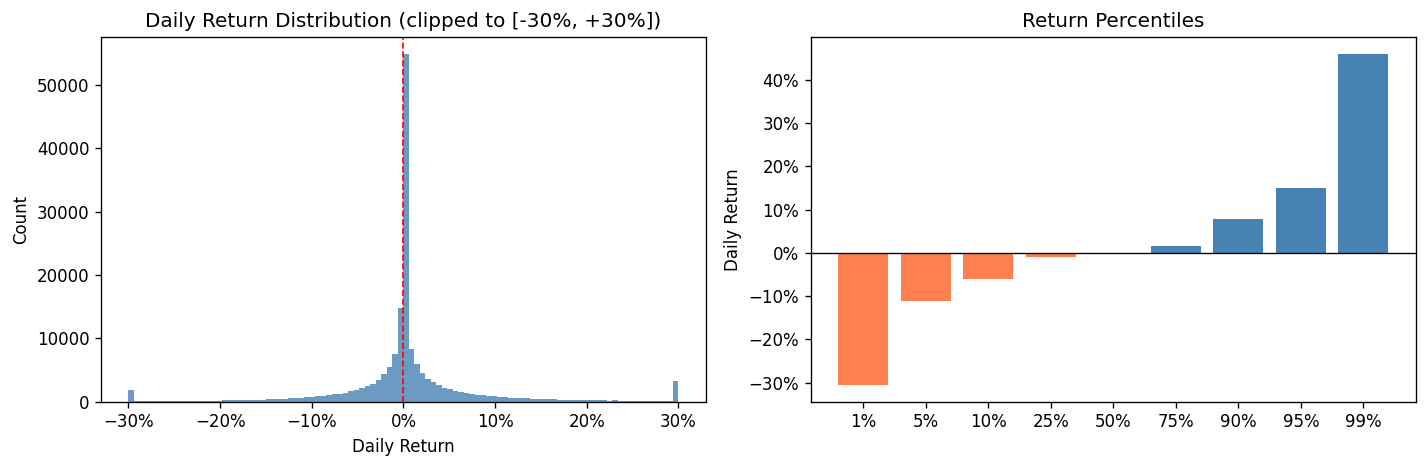

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
ax = axes[0]
clipped = returns.clip(-0.3, 0.3)
ax.hist(clipped, bins=100, color='steelblue', edgecolor='none', alpha=0.8)
ax.axvline(0, color='red', linewidth=1, linestyle='--')
ax.set_title("Daily Return Distribution (clipped to [-30%, +30%])")
ax.set_xlabel("Daily Return")
ax.set_ylabel("Count")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

# Box plot by percentile
ax = axes[1]
percs = [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
vals = [returns.quantile(p) for p in percs]
ax.bar([f"{int(p*100)}%" for p in percs], vals,
       color=['coral' if v < 0 else 'steelblue' for v in vals])
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title("Return Percentiles")
ax.set_ylabel("Daily Return")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.tight_layout()
plt.show()

## 3. Active traders over time

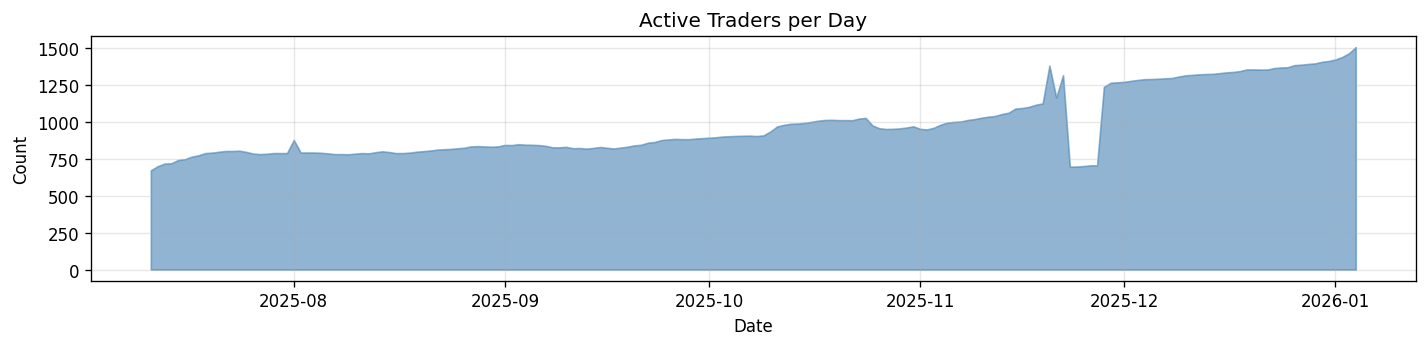

In [11]:
ret_df['date'] = pd.to_datetime(ret_df['date'])
daily_active = ret_df.dropna(subset=['daily_return']).groupby('date')['trader'].nunique()

fig, ax = plt.subplots(figsize=(12, 3))
ax.fill_between(daily_active.index, daily_active.values, alpha=0.6, color='steelblue')
ax.set_title("Active Traders per Day")
ax.set_xlabel("Date")
ax.set_ylabel("Count")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Per-trader feature summary

In [12]:
feat = pd.read_csv("../data/processed/trader_features.csv")
print(f"Total traders: {len(feat)}  |  Kept: {feat['is_kept'].sum()}")
cols = ['mean_return','std_return','max_drawdown_synth','skew_return','kurtosis_excess']
feat[cols] = feat[cols].apply(pd.to_numeric, errors='coerce')
feat[cols].describe().round(4)

Total traders: 1938  |  Kept: 1259


,mean_return,std_return,max_drawdown_synth,skew_return,kurtosis_excess
count,1938.0000,1938.0000,1938.0000,1512.0000,1512.0000
mean,0.0148,0.0837,0.3256,1.9875,19.8193
std,0.0740,0.1114,0.3545,2.9812,22.7970
min,-1.0000,0.0000,0.0000,-12.3250,-2.0000
25%,0.0000,0.0044,0.0000,0.1924,4.2833
50%,0.0043,0.0531,0.1892,1.4687,11.7312
75%,0.0125,0.1192,0.6093,3.6432,27.7716
max,1.0000,1.0142,1.0000,12.7259,161.7298
